<a href="https://colab.research.google.com/github/vicky5859/computer-vison-/blob/main/EX%3A27.%20Do%20Cropping%2C%20Copying%20and%20pasting%20image%20inside%20another%20image%20using%20OpenCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload at least one image. For best results, upload two images.


Saving bc9d108e-759e-4811-a284-f63778758ea0.png to bc9d108e-759e-4811-a284-f63778758ea0 (1).png
Only one image ('bc9d108e-759e-4811-a284-f63778758ea0 (1).png') uploaded. It will be used as both source and destination.


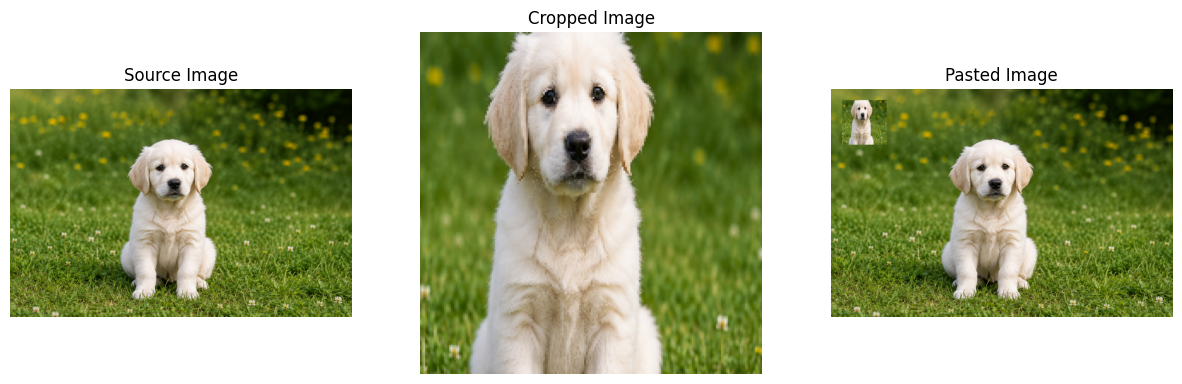

In [5]:
# EXPERIMENT 27
# Cropping, Copying and Pasting Image Inside Another Image

import cv2
import matplotlib.pyplot as plt
from google.colab import files

# Upload images
print("Please upload at least one image. For best results, upload two images.")
uploaded = files.upload()

filenames = list(uploaded.keys())

# Handle different numbers of uploaded files
if not filenames:
    print("No images uploaded. Please upload at least one image to proceed.")
    # Exit or raise an error if further processing is impossible without images
    # For now, we'll just stop here, but in a real scenario you might want to
    # wrap the rest of the code in an `else` block.
    exit()
elif len(filenames) == 1:
    print(f"Only one image ('{filenames[0]}') uploaded. It will be used as both source and destination.")
    source_filename = filenames[0]
    destination_filename = filenames[0]
elif len(filenames) >= 2:
    print(f"Using '{filenames[0]}' as source and '{filenames[1]}' as destination.")
    source_filename = filenames[0]
    destination_filename = filenames[1]

# First image = source image
source = cv2.imread(source_filename)

# Second image = destination image
destination = cv2.imread(destination_filename)

# Convert to RGB for display
source_rgb = cv2.cvtColor(source, cv2.COLOR_BGR2RGB)
destination_rgb = cv2.cvtColor(destination, cv2.COLOR_BGR2RGB)

# -----------------------------
# CROPPING FROM SOURCE IMAGE
# -----------------------------

height, width = source.shape[:2]

# Crop central portion
x1 = width // 4
y1 = height // 4
x2 = 3 * width // 4
y2 = 3 * height // 4

cropped = source[y1:y2, x1:x2]

# -----------------------------
# RESIZE CROPPED IMAGE
# -----------------------------

# Make it smaller to fit destination
# Ensure the resized image doesn't exceed destination image dimensions
dest_height, dest_width = destination.shape[:2]
resize_dim = min(200, dest_width, dest_height)
cropped = cv2.resize(cropped, (resize_dim, resize_dim))

# -----------------------------
# COPY AND PASTE
# -----------------------------

# Paste position
x = 50
y = 50

# Ensure paste position is within destination image boundaries
# And that the cropped image fits
if y + cropped.shape[0] > dest_height:
    y = dest_height - cropped.shape[0]
    if y < 0: y = 0 # If cropped image is larger than destination

if x + cropped.shape[1] > dest_width:
    x = dest_width - cropped.shape[1]
    if x < 0: x = 0 # If cropped image is larger than destination


destination[y:y+cropped.shape[0], x:x+cropped.shape[1]] = cropped

# Convert result to RGB
cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(destination, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(source_rgb)
plt.title("Source Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cropped_rgb)
plt.title("Cropped Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(result_rgb)
plt.title("Pasted Image")
plt.axis("off")

plt.show()